#  Understanding the Trends Behind Popular Spotify Songs  🎵

### An Exploratory Data Analysis using Python

## Introduction

Music streaming platforms have changed the way people discover and enjoy songs. Every track on Spotify contains several features, such as popularity, danceability, energy, tempo, and loudness, which help describe its characteristics. Studying these features can reveal interesting trends about what makes a song engaging for listeners.

In this project, I explore a Spotify songs dataset using Python and perform Exploratory Data Analysis (EDA). By creating different visualizations, I aim to understand how various audio features relate to song popularity and identify meaningful patterns within the dataset.

### Why This Project?

I chose this dataset because music is something many people connect with every day. I was curious to see whether features like danceability, energy, and tempo have any relationship with a song's popularity. This project also gave me an opportunity to practice data cleaning, visualization, and exploratory data analysis using Python.

### Project Objective

The main objective of this project is to analyze Spotify song data and understand how different audio features influence song popularity. Through data visualization and statistical analysis, this project aims to identify trends, patterns, and relationships within the dataset.

### Research Questions
Which songs are the most popular in the dataset?
Does danceability influence popularity?
Is there a relationship between energy and loudness?
Which artists appear most frequently?
How are different audio features related to one another?
What insights can be gained from Spotify song characteristics?

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### Explanation

These libraries are used for data analysis and visualization. Pandas helps in loading and organizing the dataset, NumPy supports numerical operations, while Matplotlib and Seaborn are used to create charts and graphs.

###Load Dataset

In [42]:
from google.colab import files

uploaded = files.upload()


Saving spotify.csv to spotify (1).csv


In [43]:
import pandas as pd

df = pd.read_csv("spotify.csv")

###Explanation

This line loads the Spotify dataset into a Pandas DataFrame, making it ready for exploration and analysis.

In [44]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


###Explanation

The head() function displays the first five rows of the dataset, giving an overview of its structure and available columns.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

###Explanation

This provides information about the dataset, including the number of rows, columns, data types, and missing values.

In [46]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


###Explanation

This helps identify any missing values that need to be handled before analysis.

In [49]:
df.drop_duplicates(inplace=True)

###Explanation

Removing duplicate rows improves the quality of the dataset and ensures more accurate analysis.

In [48]:
df.shape

(114000, 21)

###Explanation

This shows the total number of rows and columns in the dataset after cleaning.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

###Explanation

These libraries are used for data analysis and visualization. Pandas helps in handling data, NumPy performs numerical operations, and Matplotlib and Seaborn are used to create graphs.

In [51]:
df = pd.read_csv("spotify.csv")

###Explanation

This loads the Spotify dataset into a Pandas DataFrame so it can be analyzed.

In [52]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


###Observation

The first five records provide a quick overview of the dataset and help understand the available columns and data format.

In [53]:
df.tail()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


###Observation

The last five records confirm that the dataset has been loaded correctly and provide a view of the ending entries.

In [54]:
df.shape

(114000, 21)

###Observation

This displays the total number of rows and columns in the dataset.

In [55]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

###Observation

This lists all column names, making it easier to identify the features available for analysis.

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

###Observation

This shows the data types of each column, the number of non-null values, and the memory usage of the dataset.

In [57]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


###Observation

This provides descriptive statistics such as count, mean, standard deviation, minimum, maximum, and quartiles for the numerical columns.

In [58]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


###Observation

This identifies any missing values that may need to be handled before analysis.

In [59]:
df.duplicated().sum()

np.int64(0)

###Observation

This displays the number of duplicate records present in the dataset.

In [60]:
df.drop_duplicates(inplace=True)

###Explanation

Duplicate records are removed to improve the quality of the dataset and ensure more accurate analysis.

In [61]:
df.shape

(114000, 21)

###Observation

This confirms whether any duplicate records were removed successfully.

## Distribution of Song Popularity

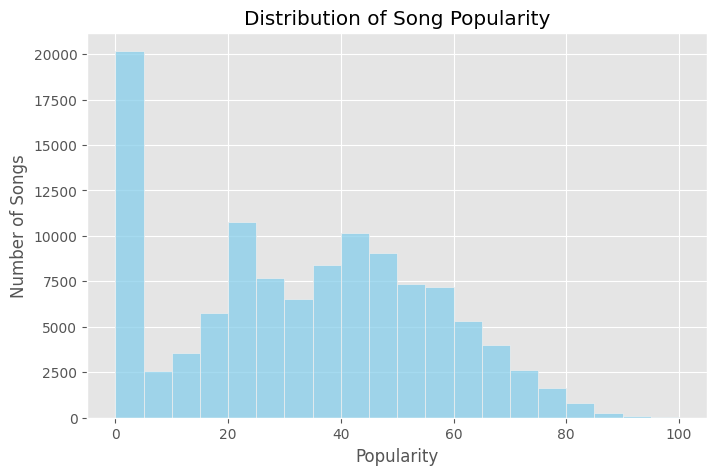

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='popularity',
    bins=20,
    color='skyblue'
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

###Explanation

This histogram shows how song popularity is distributed across the dataset.

###Observation

Most songs have low to moderate popularity, while only a few songs are highly popular.

## Top 10 Music Genres

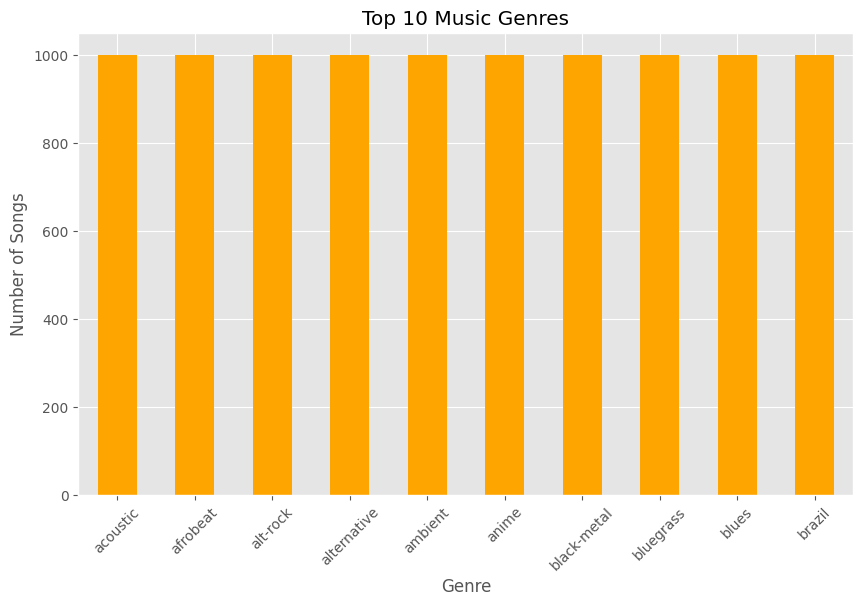

In [63]:
plt.figure(figsize=(10,6))

df['track_genre'].value_counts().head(10).plot(
    kind='bar',
    color='orange'
)

plt.title("Top 10 Music Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")

plt.xticks(rotation=45)

plt.show()

###Explanation

This chart displays the ten genres with the highest number of songs.

###Observation

Some genres contain significantly more songs than others, indicating higher representation in the dataset.

## Top 10 Artists with Most Songs

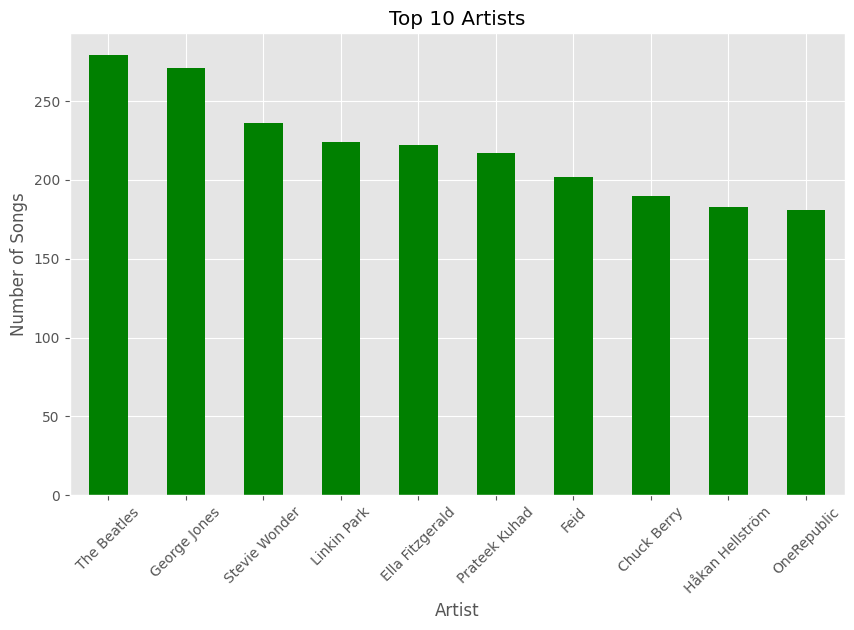

In [64]:
plt.figure(figsize=(10,6))

df['artists'].value_counts().head(10).plot(
    kind='bar',
    color='green'
)

plt.title("Top 10 Artists")
plt.xlabel("Artist")
plt.ylabel("Number of Songs")

plt.xticks(rotation=45)

plt.show()

###Explanation

This graph shows the artists with the highest number of tracks in the dataset.

###Observation

A few artists dominate the dataset by contributing many songs.

## Danceability vs Popularity

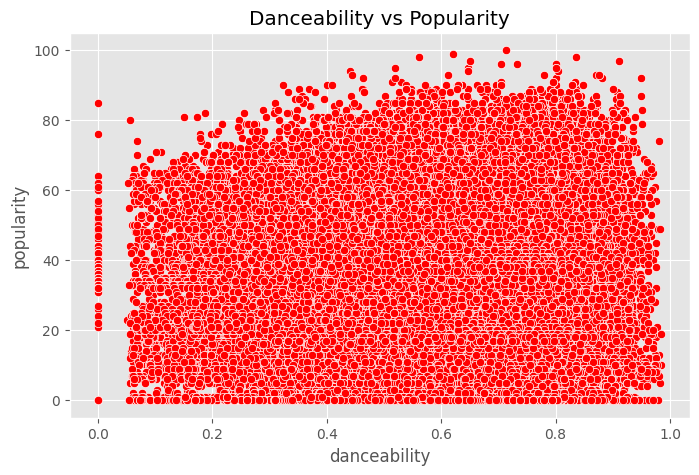

In [65]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='danceability',
    y='popularity',
    color='red'
)

plt.title("Danceability vs Popularity")

plt.show()

###Observation

The relationship between danceability and popularity appears moderate, suggesting danceability alone does not determine popularity.

## Distribution of Energy

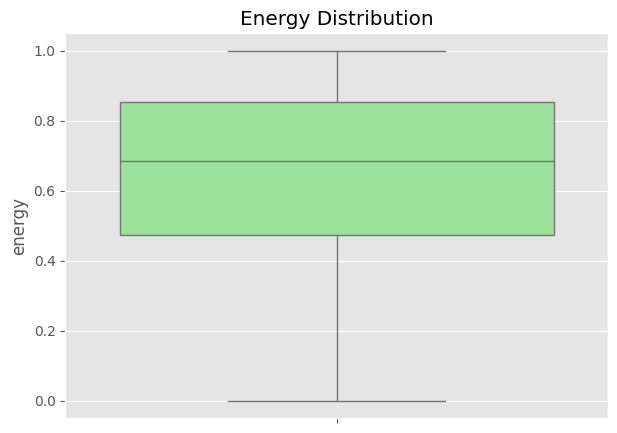

In [66]:
plt.figure(figsize=(7,5))

sns.boxplot(
    y=df['energy'],
    color='lightgreen'
)

plt.title("Energy Distribution")

plt.show()

###Observation

Most songs have medium to high energy levels, while a few songs appear as outliers.

## Correlation Between Audio Features

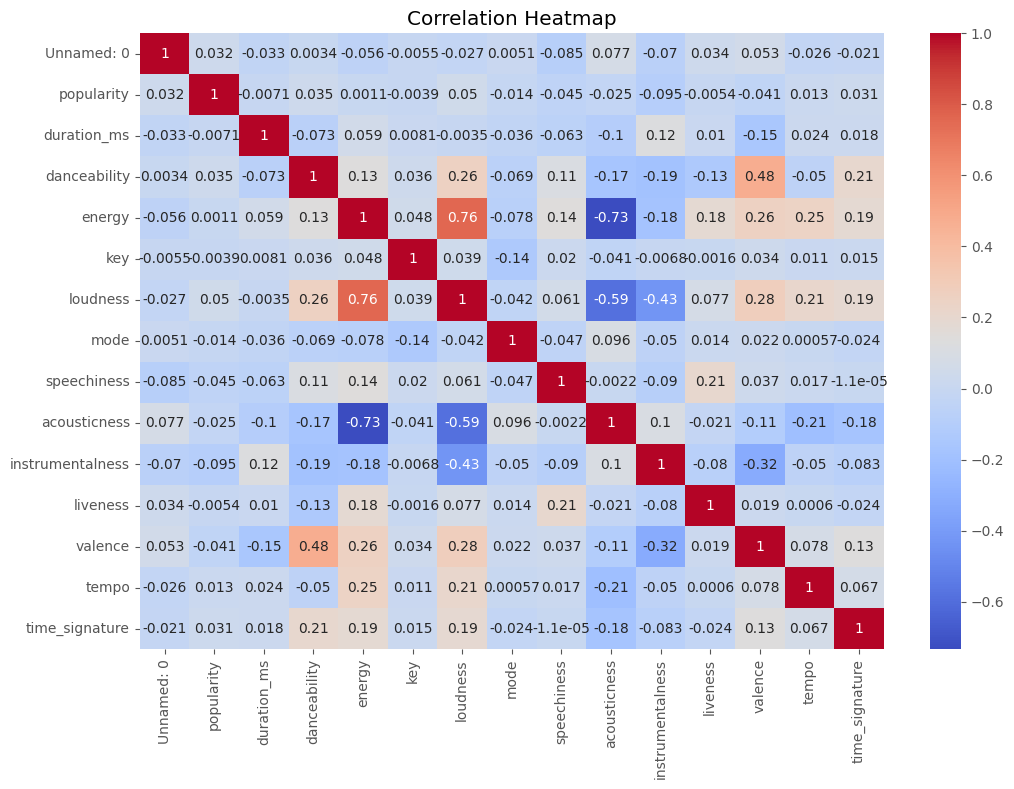

In [67]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

###Observation

The heatmap highlights positive and negative relationships among the numerical audio features.

## Top 10 Most Popular Songs

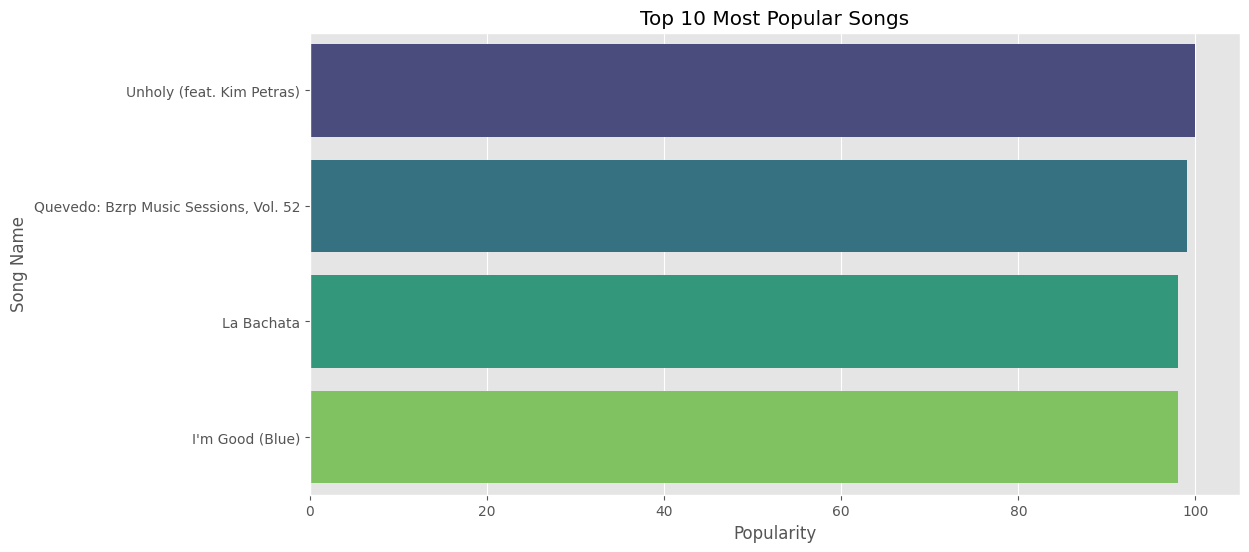

In [68]:
top_songs = df.sort_values(by='popularity', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_songs,
    x='popularity',
    y='track_name',
    hue='track_name',
    legend=False,
    palette='viridis'
)

plt.title("Top 10 Most Popular Songs")
plt.xlabel("Popularity")
plt.ylabel("Song Name")

plt.show()

###Observation

The graph highlights the songs with the highest popularity scores in the dataset.

## Explicit vs Non-Explicit Songs

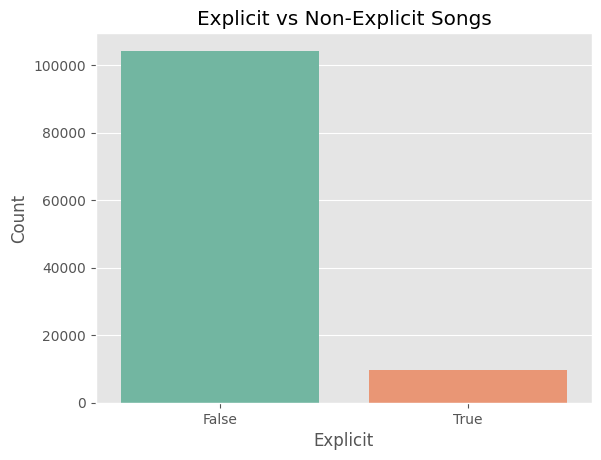

In [73]:
sns.countplot(
    data=df,
    x='explicit',
    hue='explicit',
    palette='Set2',
    legend=False
)

plt.title("Explicit vs Non-Explicit Songs")
plt.xlabel("Explicit")
plt.ylabel("Count")
plt.show()

###Observation

This chart compares the number of explicit and non-explicit songs.

## Distribution of Song Tempo

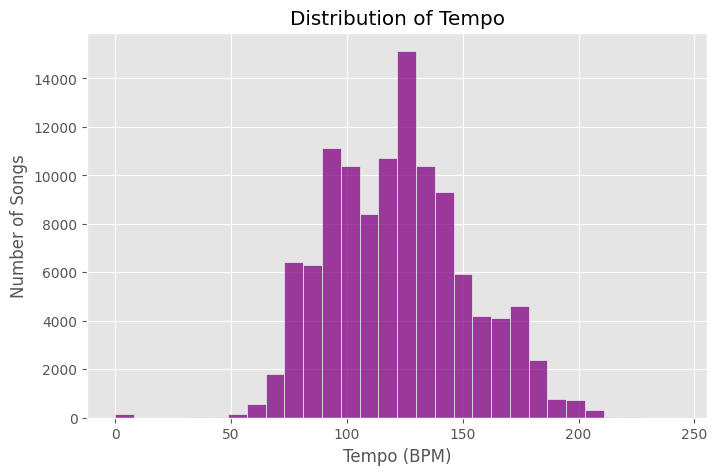

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tempo',
    bins=30,
    color='purple'
)

plt.title("Distribution of Tempo")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Number of Songs")

plt.show()

###Observation

Most songs fall within a moderate tempo range, while very slow and very fast songs are less common.

## Average Popularity by Genre

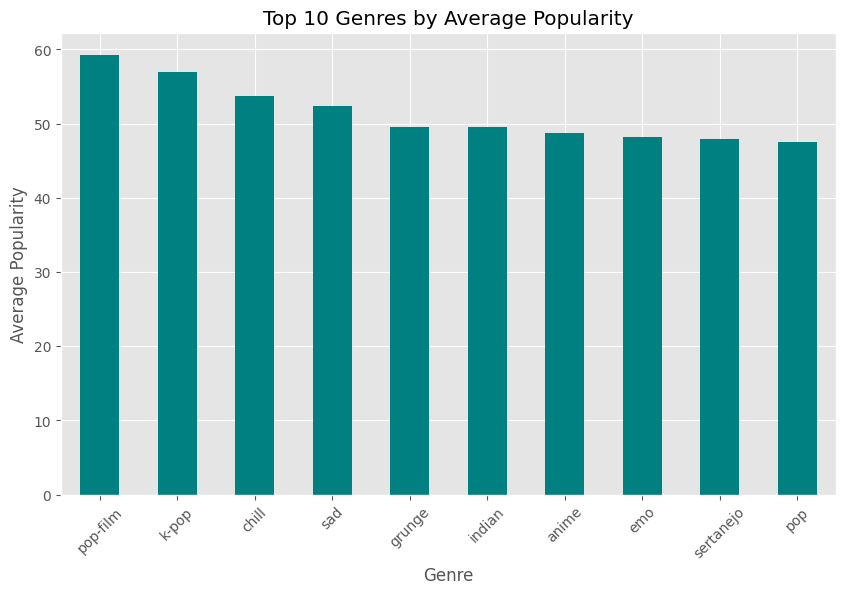

In [71]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

genre_popularity.plot(
    kind='bar',
    color='teal'
)

plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")

plt.xticks(rotation=45)

plt.show()

###Observation

Some genres consistently achieve higher average popularity than others.

## Statistical Analysis

In [72]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


###Explanation

This table summarizes the numerical features by displaying count, mean, standard deviation, minimum, maximum, and quartile values.

# Key Findings

• Most songs have moderate popularity scores.

• Danceability shows a slight positive relationship with popularity.

• Energy levels are generally medium to high.

• Some music genres are represented much more frequently than others.

• Popular songs are distributed across multiple genres rather than belonging to only one category.

• Audio features such as danceability, energy, and tempo influence songs differently, indicating that popularity depends on multiple factors.

# Conclusion

This project explored a Spotify songs dataset using Python, Pandas, Matplotlib, and Seaborn.

After cleaning and analyzing the dataset, several interesting patterns were observed regarding song popularity, genres, and audio characteristics.

The visualizations showed that music popularity is influenced by multiple features rather than a single attribute. This project also strengthened my understanding of Exploratory Data Analysis (EDA), data visualization, and data interpretation using Python.

# References

• Spotify Songs Dataset

• Kaggle

• Pandas Documentation

• Matplotlib Documentation

• Seaborn Documentation